# Imports
Functions are kept in a seperate file to not clutter this report uneccessarily. Most imports are in functions.py

In [1]:
from functions import *

I0000 00:00:1779191972.957671   70085 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779191972.957937   70085 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779191972.982339   70085 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779191973.574234   70085 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

# Read and view data
Setting path variables to the training and test data.

Makes a dataset for training, validation and testing.

Show general information about the data. Shape and the different classes. Also confirms that 20% of the total data is for testing. The remaining 80% of the data consists of training and validation data.

In [2]:
train_path = "Data/train/"
test_path = "Data/test/"

# Create a training set
print("Train dataset:")
train_ds, class_names = load_images_from_dir(train_path, (48, 48), "training")

# Create a training set
print("\nValidation dataset:")
val_ds, _ = load_images_from_dir(train_path, (48, 48), "validation")

# Create a test set
print("\nTest dataset:")
test_ds, _ = load_images_from_dir(test_path, (48, 48), "")

# Check classes
print(f"\nClasses: {class_names}")

# View class names for training set
train_df = return_class_count_df(train_path)
print(f"\nTraining/Validation classes: \n{train_df}")

# View class names for test set
test_df = return_class_count_df(test_path)
print(f"\nTest classes: \n{test_df}")

# Check if the train and test data are split 80/20
print(f"\nPercentage of data in train/val dataset: {count_files(train_path) / (count_files(train_path) + count_files(test_path)):0.2f}")
print(f"Percentage of data in test dataset: {count_files(test_path) / (count_files(train_path) + count_files(test_path)):0.2f}")

Train dataset:
Found 28709 files belonging to 7 classes.
Using 22968 files for training.

Validation dataset:


E0000 00:00:1779191973.990987   70085 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 28709 files belonging to 7 classes.
Using 5741 files for validation.

Test dataset:
Found 7178 files belonging to 7 classes.

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Training/Validation classes: 
      Class  Images
0   disgust     436
1   neutral    4965
2  surprise    3171
3     happy    7215
4      fear    4097
5       sad    4830
6     angry    3995

Test classes: 
      Class  Images
0   disgust     111
1   neutral    1233
2  surprise     831
3     happy    1774
4      fear    1024
5       sad    1247
6     angry     958

Percentage of data in train/val dataset: 0.80
Percentage of data in test dataset: 0.20


Plotting n number of images to get an idea of what the data consists of.

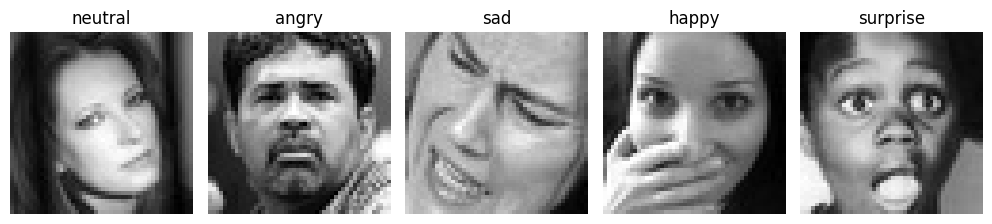

In [3]:
plot_n_images(train_ds, class_names, 5)

# Model 1 - Baseline
This model does not contain any forms of regularization. Exclusively different layers and activations.

This model acts as the baseline.

In [4]:
model_layers = [
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(7, activation="softmax")
]

model_test = create_model(model_layers)

Returns the model and history after training.

In [5]:
model, history = train_model(model_test, train_ds, val_ds, 20, None)

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3542 - loss: 1.6431 - val_accuracy: 0.4262 - val_loss: 1.5059
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4551 - loss: 1.4292 - val_accuracy: 0.4632 - val_loss: 1.4045
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4948 - loss: 1.3287 - val_accuracy: 0.4816 - val_loss: 1.3469
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5235 - loss: 1.2569 - val_accuracy: 0.4813 - val_loss: 1.3397
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5527 - loss: 1.1851 - val_accuracy: 0.4957 - val_loss: 1.3126
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5788 - loss: 1.1179 - val_accuracy: 0.4872 - val_loss: 1.3318
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6060 - loss: 1.0532 - val_accuracy: 0.4851 - val_loss: 1.3450
Epoch 8/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6335 - loss: 0.9901 - val_accuracy: 0.

# Model 1 conclusion
There are clear patterns of overfitting. Training and validation data are diverging rapidly after roughly epoch 2-3.

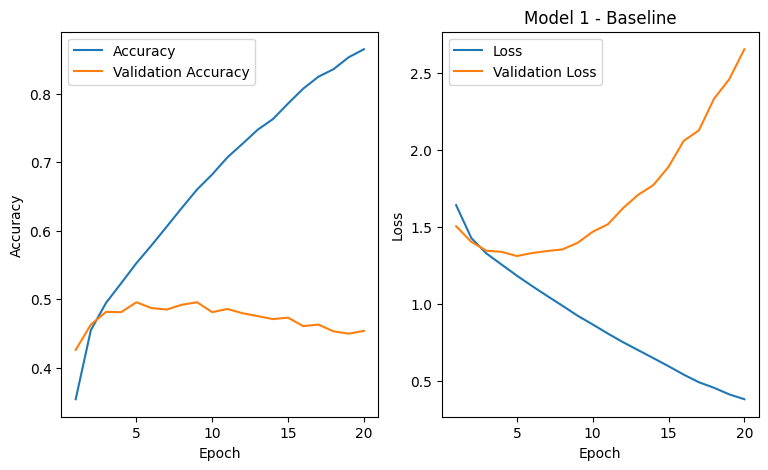

In [6]:
plot_history_data(history.history, "Model 1 - Baseline")